In [ ]:
from hiprof import HPFalsifier

Consider the following DAG.

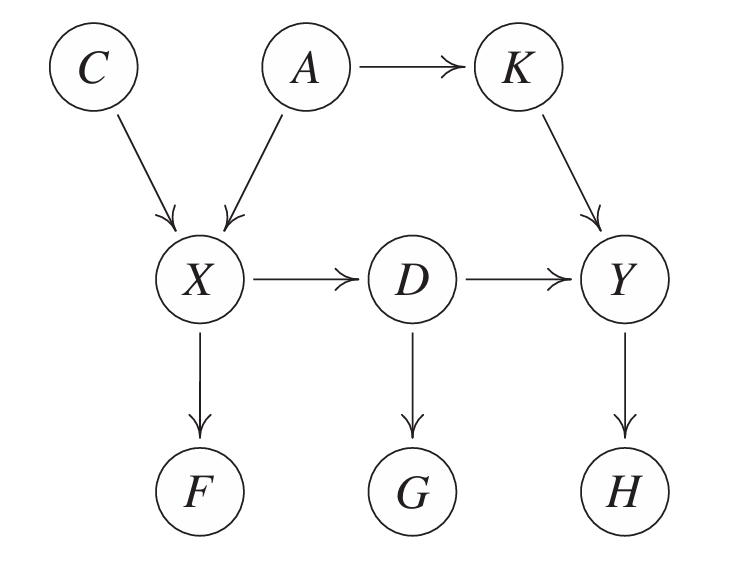

We instantiate the falsifier by specify the graph, treatments and outcomes.

In [ ]:
falsifier = HPFalsifier(
    graph="C -> A; A -> X; A -> K; K -> Y; X -> D; D -> Y; X -> F; D -> G; Y -> H",
    treatments="X",
    outcomes="Y",
)

Then, we define the observational formula.

Given the DAG, the backdoor criterion implies that a valid adjustment set (VAS) is $\{A, K\}$. Therefore, the following formula should correctly identify the target interventional distribution.

In [ ]:
formula = "sum_{A,K} { p(Y | X, A, K) p(A, K) }"
falsifier.check(formula)

A different VAS is $\{A, K, F\}$, which should also pass the check.

In [ ]:
formula = "sum_{A,K,F} { p(Y | X, A, K, F) p(A, K, F) }"
falsifier.check(formula)

$\{A, K, G\}$, instead, is *not* a VAS, since $G$ is a descendant of a node on a directed path from $X$ to $Y$. Therefore, it should not pass the check.

In [ ]:
formula = "sum_{A,K,G} { p(Y | X, A, K, G) p(A, K, G) }"
falsifier.check(formula)

Now consider the following DAG.

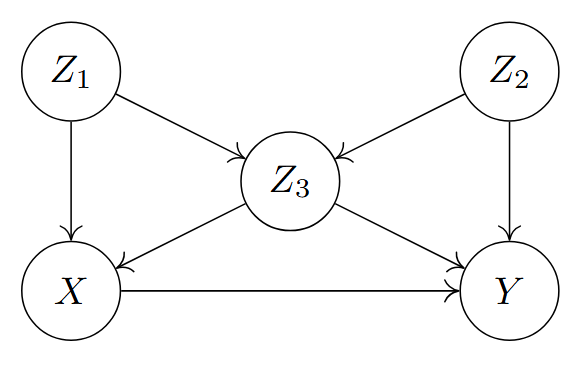

In this case, we need to block the path $X\leftarrow Z_3\rightarrow Y$. If we condition on $Z_3$, we open the path $X\leftarrow Z_1\rightarrow Z_3\leftarrow Z_2\rightarrow Y$, which we also need to block.

In [ ]:
falsifier = HPFalsifier(
    graph="Z1 -> Z3; Z2 -> Z3; Z1 -> X; Z2 -> Y; Z3 -> X; Z3 -> Y; X -> Y",
    treatments="X",
    outcomes="Y",
)

Therefore, $\{Z_3\}$ is *not* a VAS, and the falsifier should yield $\texttt{False}$.

In [ ]:
formula = "sum_{Z3} { p(Y | X, Z3) p(Z3) }"
falsifier.check(formula)

$\{Z_1, Z_3\}$ should be a VAS.

In [ ]:
formula = "sum_{Z1, Z3} { p(Y | X, Z1, Z3) p(Z1, Z3) }"
falsifier.check(formula)

Finally, consider the following DAG.

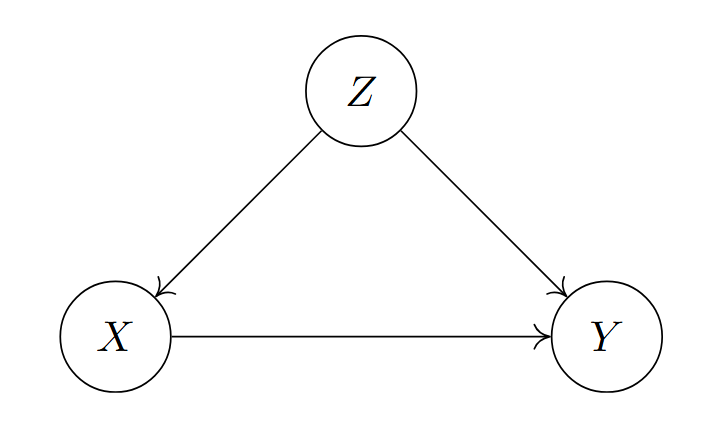

In [ ]:
falsifier = HPFalsifier(
    graph="X -> Y; Z -> X; Z -> Y",
    treatments="X",
    outcomes="Y",
)

If we are interested in the causal effect from $X$ to $Y$, we need to block the path $X\leftarrow Z\rightarrow Y$.

In [ ]:
formula = "sum_{Z} { p(Y | X, Z) p(Z) }"
falsifier.check(formula)

If we are instead interested in the causal effect from $Z$ to $Y$, the following formula should suffice.

In [ ]:
falsifier = HPFalsifier(
    graph="X -> Y; Z -> X; Z -> Y",
    treatments="Z",
    outcomes="Y",
)
formula = "p(Y | Z)"
falsifier.check(formula)

### Example with multiple treatments

In [ ]:
falsifier = HPFalsifier(
    graph="X1 -> Y; X2 -> Y; C -> X1; C -> X2; C -> Y",
    treatments=["X1", "X2"],
    outcomes="Y",
)

In [ ]:
formula = "sum_{C} {p(Y | X1, X2, C) p(C)}"
falsifier.check(formula)

### Example with multiple outcomes

In [ ]:
falsifier = HPFalsifier(
    graph="X1 -> Y; X2 -> Y; C -> X1; C -> X2; C -> Y; Y -> Z",
    treatments=["X1", "X2"],
    outcomes=["Y", "Z"],
)

In [ ]:
formula = "sum_{C} {p(Y, Z | X1, X2, C) p(C)}"
falsifier.check(formula)

Now you can specify your DAG and query and test any formula involving marginalisation, conditioning, product and internal conditional division!